<a href="https://colab.research.google.com/github/fathimashafna362-cmyk/ADD_ON_COURSE/blob/main/AI_WORKSHOP_Day3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
print(os.listdir("/content"))

['.config', 'pets (2).zip', 'sample_data']


In [ ]:
from zipfile import ZipFile

with ZipFile("/content/pets (3).zip", "r") as zip_ref:
    zip_ref.extractall("/content/images")

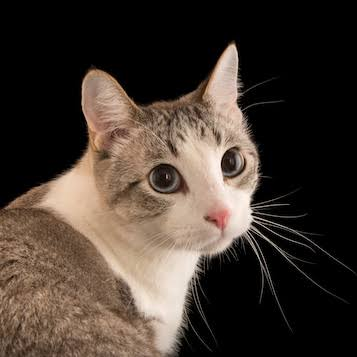

In [ ]:

from PIL import Image

image_folder = "/content/images/pets"

image_name = os.listdir(image_folder)[0]

image_path = os.path.join(image_folder, image_name)

image = Image.open(image_path)

image

In [ ]:
print(image.mode)

RGB


In [ ]:
images=[]
for file in os.listdir(image_folder):
  image_path = os.path.join(image_folder, file)
  image = Image.open(image_path)
  images.append(image)
print("Total images",(len(images)))

Total images 20


In [ ]:
resized_images=[]
for img in images:
  resized=image.resize((128,128))
  resized_images.append(resized)
print("Total Resized Images: ",len(resized_images))

Total Resized Images:  20


In [ ]:
import numpy as np
image_arrays=[]
for image in resized_images:
  image_array=np.array(image)
  image_arrays.append(image_array)
print("Total Image Arrays: ",len(image_arrays))



Total Image Arrays:  20


In [ ]:
print(image_arrays[0].shape)

(128, 128, 3)


In [ ]:
normalized_images=[]   # normalizing converting the images into same scale
for image in image_arrays:
  normalized=image/255.0
  normalized_images.append(normalized)
print("Total Normalized Images: ",len(normalized_images))

Total Normalized Images:  20


In [ ]:
print(normalized_images[0][0,0])

[0.33333333 0.27058824 0.18039216]


In [ ]:
# creating labels for cat and dog

labels=[]
for file in os.listdir(image_folder):
  if "cat" in file.lower():
    labels.append(0)
  elif "dog" in file.lower():
    labels.append(1)
print(labels)

[0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0]


In [ ]:
X=np.array(normalized_images)
y=np.array(labels)

In [ ]:
print(type(X))
print(X.shape) # it is 4 dimension

print(type(y))
print(y.shape)

<class 'numpy.ndarray'>
(20, 128, 128, 3)
<class 'numpy.ndarray'>
(20,)


In [ ]:
# logistic expression cannot understand this it required data in 2D
#  so we must convert the 4D to 2D this process
# before flattening (20,128,128,3) 20 images after flatening
# 128 x 128 x 3 49142 -> (20,4912) -2D
# Logistic Regression expects data in this table format:
# Rows = Samples
# Columns = Features

In [ ]:
X=X.reshape(X.shape[0],-1) #X.shape[0] keep the 20 images and -1 indicate to calcuate the rest part
print(X.shape)

(20, 49152)


In [ ]:
#  Train-Test Split
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)  #random_state=42,The data is shuffled before splitting.
print(X_train.shape)
print(X_test.shape)

(16, 49152)
(4, 49152)


In [ ]:
print(X_train.shape)
print(X_test.shape)

print(y_train.shape)
print(y_test.shape)

(16, 49152)
(4, 49152)
(16,)
(4,)


In [ ]:
from sklearn.linear_model import LogisticRegression
model=LogisticRegression()
model.fit(X_train,y_train)

LogisticRegression()

In [ ]:
y_prediction=model.predict(X_test)

In [ ]:
print(y_prediction)

[0 0 0 0]


In [ ]:
print("Actual Labels: ",y_test)
print("predicted Labels: ",y_prediction)

Actual Labels:  [0 0 1 1]
predicted Labels:  [0 0 0 0]


In [ ]:
#  calculate accuracy
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_prediction)

print("Accuracy:", accuracy)

Accuracy: 0.5


just testing with an image

In [ ]:
from PIL import Image
image=Image.open("/content/cat.jpg")

In [ ]:
image=image.resize((128,128))

In [ ]:
image=np.array(image)

In [ ]:
image=image/255.5

In [ ]:
image=image.reshape(1,-1)

In [ ]:
prediction=model.predict(image)
print(prediction)

[0]


In [ ]:
if prediction[0]==0:
  print("Cat")
else:
  print("Dog")

Cat


Testing 2

In [ ]:
im=Image.open("/content/cat image-35327568.avif")

In [ ]:
im=im.resize((128,128))

In [ ]:
im=np.array(im)

In [ ]:
im=im/255.0

In [ ]:
im=im.reshape(1,-1)

In [ ]:
prediction=model.predict(im)
print(prediction)

[0]


In [ ]:
if prediction[0]==0:
  print("Cat")
else:
  print("Dog")

Cat


In [ ]:
img=Image.open("/content/dog.jpg")

In [ ]:
img=img.resize((128,128))

In [ ]:
img=np.array(img)

In [ ]:
img=img/255.0

In [ ]:
img=img.reshape(1,-1)

In [ ]:
prediction=model.predict(img)
print(prediction)

[0]


In [ ]:
if prediction[0]==0:
  print("Cat")
else:
  print("Dog")

Cat
